In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [13]:
df.dtypes

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [11]:
df["Дата"] = pd.to_datetime(df["Дата"])

Сгруппируйте данные по дате, посчитайте количество продаж

In [14]:
grouped_df = df.groupby("Дата").size()
print(grouped_df)

Дата
2018-01-04    1840
2018-01-05    1301
2018-01-06    1306
2018-01-07    1322
2018-01-09    1719
              ... 
2018-08-26    1462
2018-08-28    1731
2018-08-29    1497
2018-08-30    1445
2018-08-31    1366
Length: 205, dtype: int64


Вывести несколько первых строк сгруппированных данных

In [15]:
print(grouped_df.head())

Дата
2018-01-04    1840
2018-01-05    1301
2018-01-06    1306
2018-01-07    1322
2018-01-09    1719
dtype: int64


Нарисуйте график продаж у `grouped_df`

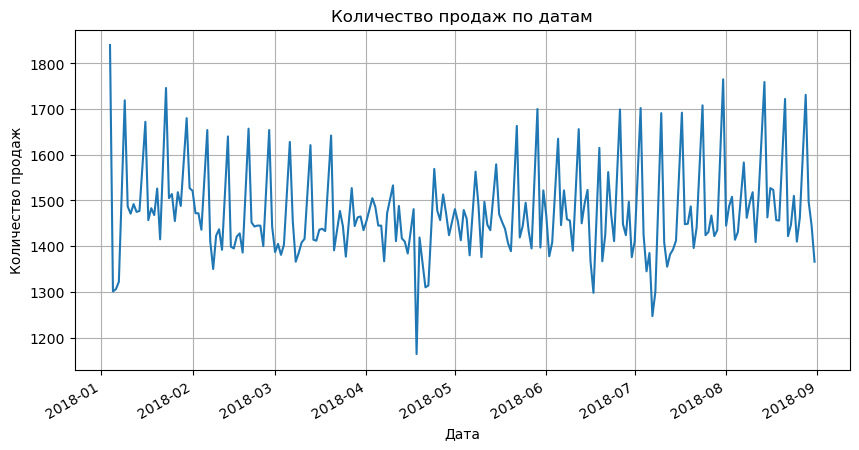

In [16]:
grouped_df.plot(figsize=(10, 5))

plt.title("Количество продаж по датам")
plt.xlabel("Дата")
plt.ylabel("Количество продаж")
plt.grid()

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [ ]:
Согласно графику в январе 2018 года продаж было больше всего, а самые низкие продажи пришлись на мй месяц 2018 года. 
В остальных месяцех продажи более стабильные.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [24]:
Q1 = grouped_df["Количество продаж"].quantile(0.25)
Q3 = grouped_df["Количество продаж"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = grouped_df[grouped_df["Количество продаж"] > upper_bound]

max_outlier = outliers.sort_values("Количество продаж", ascending=False).head(1)
print(max_outlier)

        Дата  Количество продаж
0 2018-01-04               1840


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [26]:
#фильтр по месяцам 

df_summer = df[df["Дата"].dt.month.isin([6, 7, 8])]

#среда

df_wed = df_summer[df_summer["Дата"].dt.weekday == 2]

#группировать 

grouped = df_wed.groupby(["Склад", "Номенклатура"])["Количество"].sum().reset_index()

#топовый товар по каждому складу 

top_products = grouped.loc[grouped.groupby("Склад")["Количество"].idxmax()]
print(top_products)

    Склад Номенклатура  Количество
1       1    product_1        2981
24      2    product_1        2887
46      3    product_1        2267
69      4    product_1        2385
92      5    product_1        1956


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [115]:
weather = pd.read_csv(
    "weather.csv.gz",
    compression="gzip",
    sep=";",
    encoding="utf-8",
    skiprows=6,
    on_bad_lines="skip"
)

In [116]:
print(weather.iloc[0])
print(weather.columns)

Местное время в Астане                                                  8.2
T                                                                     736.6
Po                                                                    768.3
P                                                                       0.2
Pa                                                                     78.0
U                                            Ветер, дующий с северо-востока
DD                                                                        4
Ff                                                                      NaN
ff10                                                                    NaN
ff3                                                               70 – 80%.
N                                    Состояние неба в общем не изменилось. 
WW                                                          Ливень (ливни).
W1                        Облака покрывали более половины неба в течение...
W2          

In [117]:
weather = weather.reset_index()

In [118]:
weather = weather.rename(columns={"index": "Дата"})

In [119]:
weather["Дата"] = pd.to_datetime(weather["Дата"], dayfirst=True)

In [120]:
print(weather["Дата"].head())
print(weather["Дата"].dtype)
print(weather["Дата"].isna().sum())
print(weather["Дата"].min(), weather["Дата"].max())

0   2018-08-31 23:00:00
1   2018-08-31 20:00:00
2   2018-08-31 17:00:00
3   2018-08-31 14:00:00
4   2018-08-31 11:00:00
Name: Дата, dtype: datetime64[ns]
datetime64[ns]
0
2018-01-04 02:00:00 2018-08-31 23:00:00


In [121]:
weather["T"] = pd.to_numeric(weather["T"], errors="coerce")

In [122]:
temp_daily = weather.groupby(weather["Дата"].dt.date)["T"].mean().reset_index()
temp_daily["Дата"] = pd.to_datetime(temp_daily["Дата"])

In [123]:
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"])

In [124]:
merged = grouped_df.merge(temp_daily, on="Дата", how="inner")

In [125]:
print(merged.shape)
print(merged.head())

(205, 3)
        Дата  Количество продаж         T
0 2018-01-04               1840  744.6625
1 2018-01-05               1301  745.3000
2 2018-01-06               1306  744.2500
3 2018-01-07               1322  742.2375
4 2018-01-09               1719  734.1875


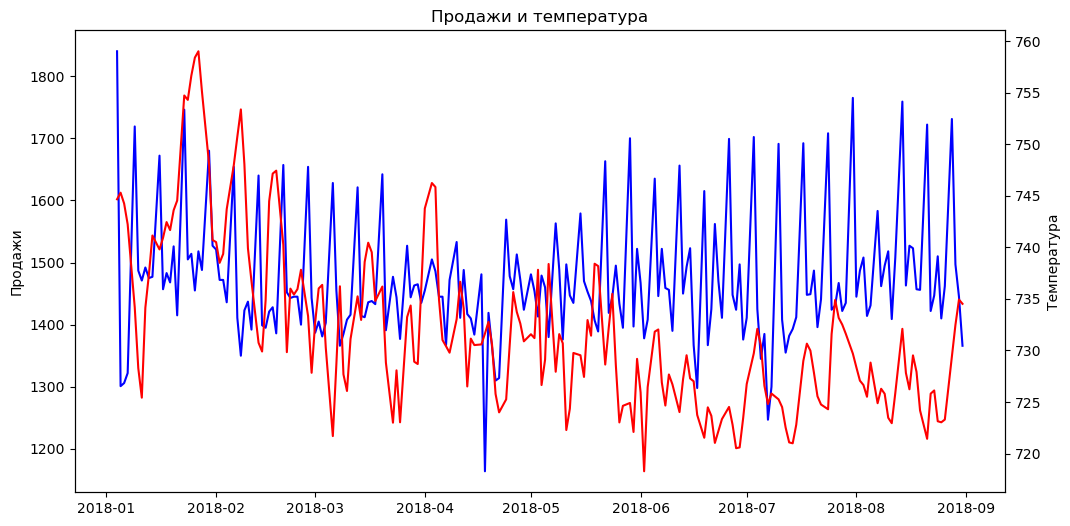

In [126]:
#график продажи и темпа

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(merged["Дата"], merged["Количество продаж"], color="blue")
ax1.set_ylabel("Продажи")

ax2 = ax1.twinx()
ax2.plot(merged["Дата"], merged["T"], color="red")
ax2.set_ylabel("Температура")

plt.title("Продажи и температура")
plt.xticks(rotation=45)
plt.show()

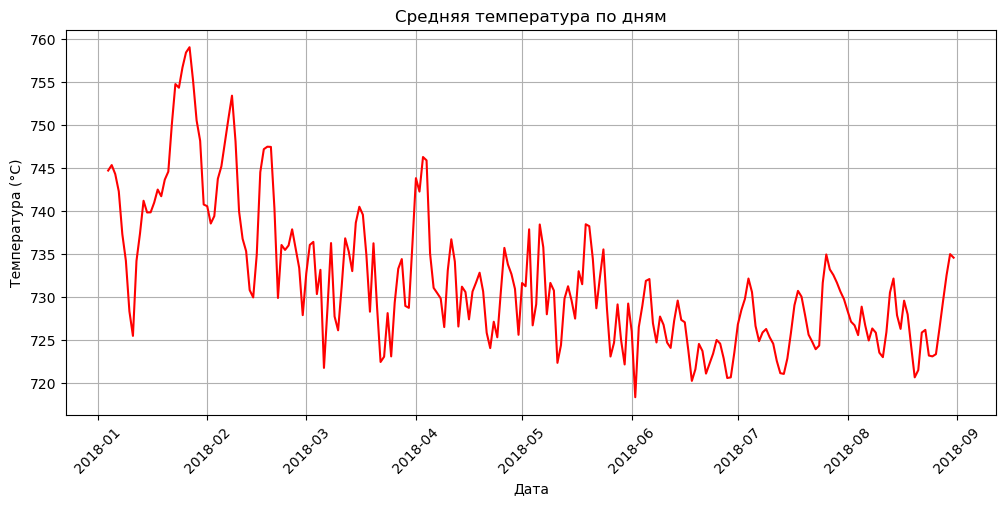

In [127]:
#отдельный график температуры


plt.figure(figsize=(12,5))

plt.plot(temp_daily["Дата"], temp_daily["T"], color="red")

plt.title("Средняя температура по дням")
plt.xlabel("Дата")
plt.ylabel("Температура (°C)")
plt.xticks(rotation=45)

plt.grid(True)
plt.show()